In [12]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
from rdkit.Chem import PandasTools
import pandas as pd

ddir = 'data/'
df = pd.read_csv(os.path.join(ddir,'partial_data.csv'))
df.columns = ['smiles']

PandasTools.AddMoleculeColumnToFrame(df,'smiles','mol',includeFingerprints=False)

from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True

from graph_augs import add_atom_to_mol
from rdkit_utils import *

def MolGraphFromSmiles(smiles):
    return get_rwmol( Chem.MolFromSmiles(smiles) )

df['length'] = df.smiles.apply(lambda x: MolGraphFromSmiles(x).GetNumAtoms())
df = df.sort_values('length',ascending=True)
# displaydf(df.head(5))

# df = df[20:40]
df = df[10:15]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


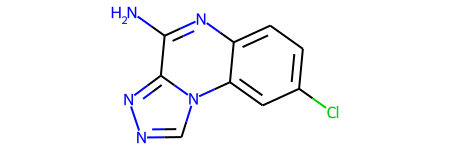

In [13]:
from graph_augs import *

s = canonicalize_smiles('Nc1nc2ccc(Cl)cc2n2cnnc12')
mol = Chem.MolFromSmiles(s)
mol_aug = add_atom_to_mol(mol, 'N', 4)

mol
# molgraph = MolGraphFromSmiles('Nc1nc2ccc(Cl)cc2n2cnnc12')
# molgraph_new = add_atom_to_mol(molgraph, 'N', 4)
# molgraph_new

In [14]:
# new_mol = molgraph_new.GetMol()
# smiles = Chem.MolToSmiles(new_mol)
# smiles2 = Chem.MolToSmiles( Chem.MolFromSmiles(smiles) )
# smiles, smiles2

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


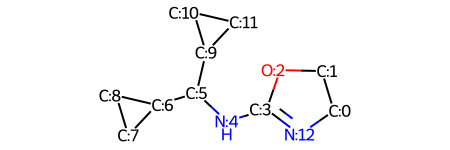

AUGMENTED MOLECULES
2 Explicit valence for atom # 2 O, 3, is greater than permitted
3 Explicit valence for atom # 3 C, 5, is greater than permitted
12 Explicit valence for atom # 12 N, 4, is greater than permitted
[2, 3, 12]


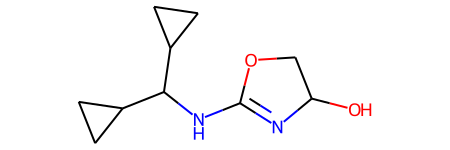

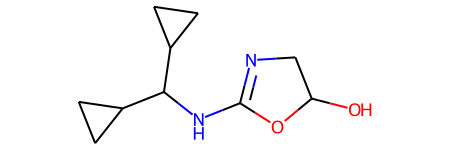

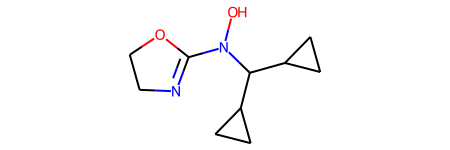

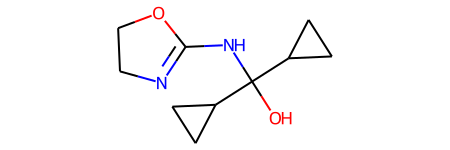

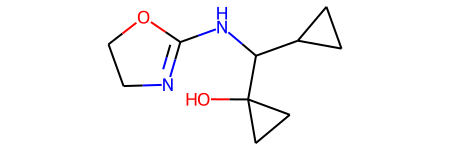

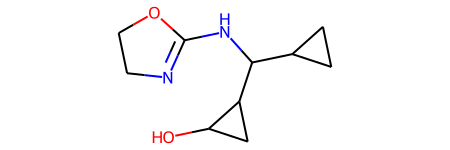

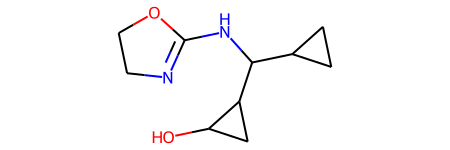

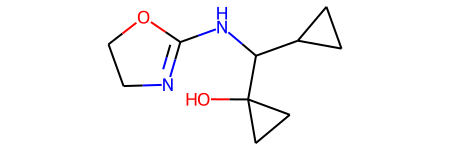

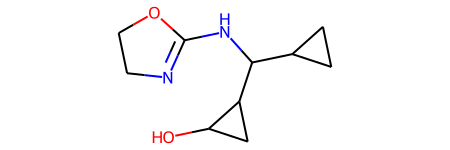

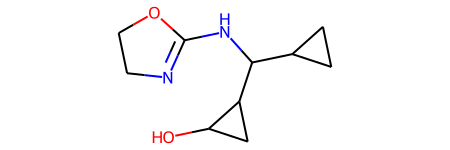

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


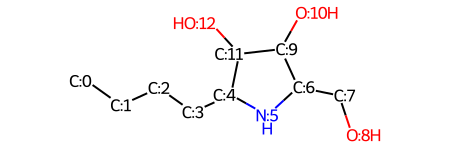

AUGMENTED MOLECULES
[]


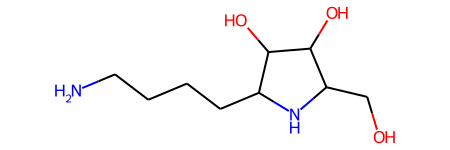

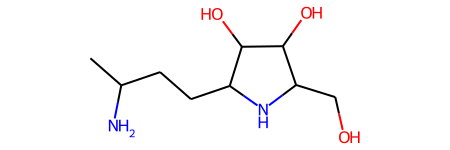

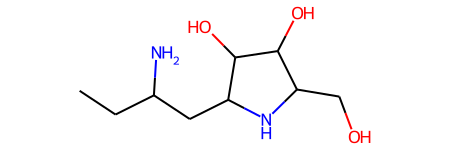

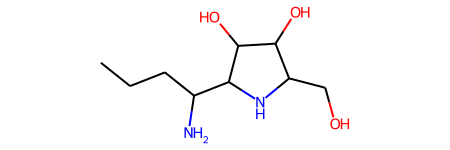

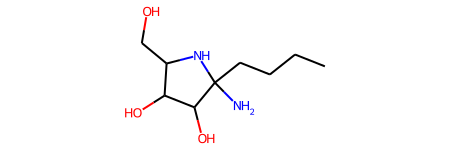

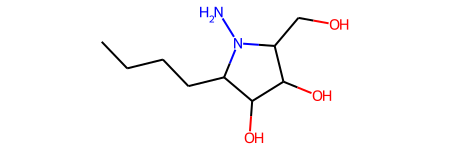

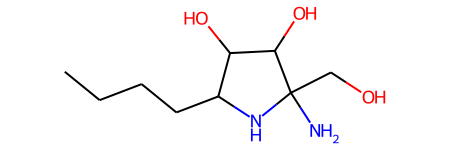

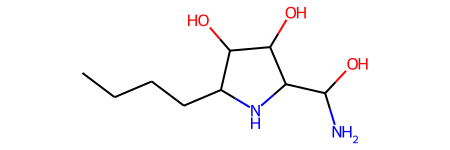

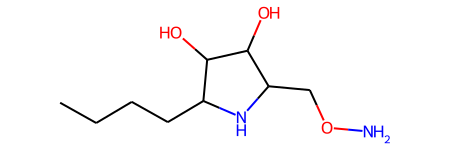

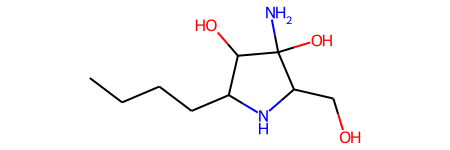

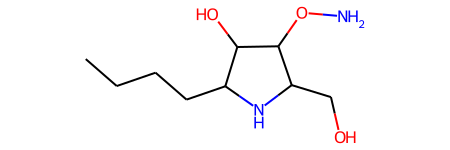

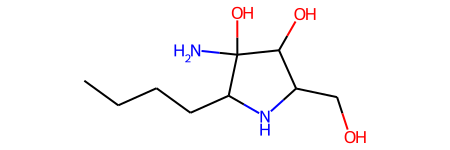

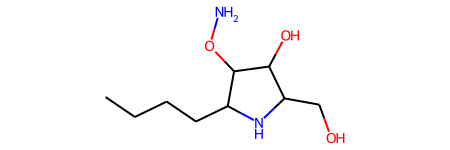

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


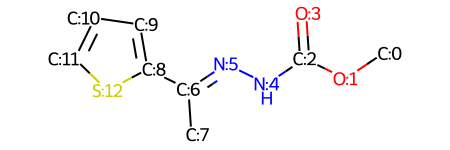

AUGMENTED MOLECULES
1 Explicit valence for atom # 1 O, 3, is greater than permitted
2 Explicit valence for atom # 2 C, 5, is greater than permitted
3 Explicit valence for atom # 3 O, 3, is greater than permitted
5 Explicit valence for atom # 5 N, 4, is greater than permitted
6 Explicit valence for atom # 6 C, 5, is greater than permitted
[1, 2, 3, 5, 6, 8, 12]


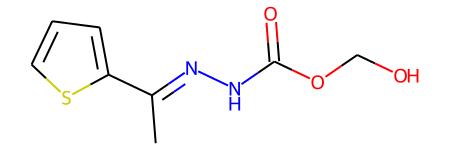

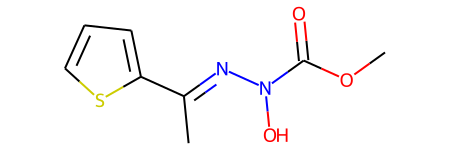

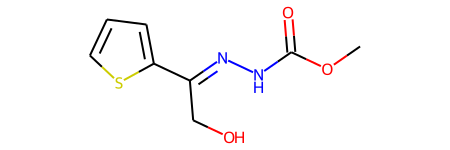

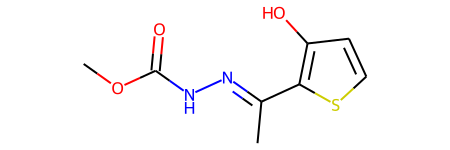

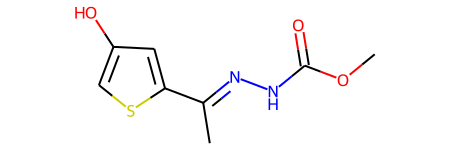

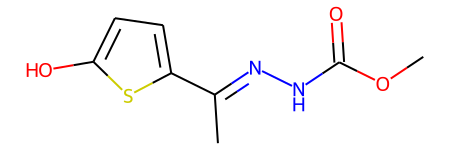

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


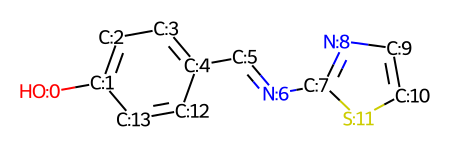

AUGMENTED MOLECULES
6 Explicit valence for atom # 6 N, 4, is greater than permitted
[1, 4, 6, 7, 8, 11]


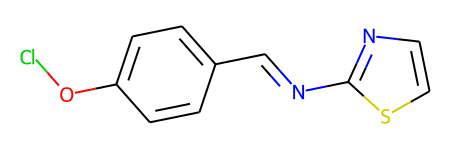

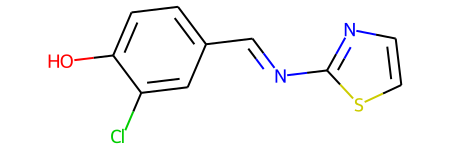

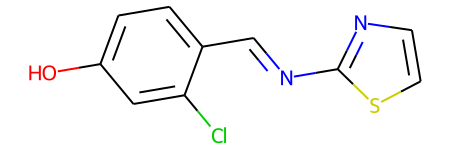

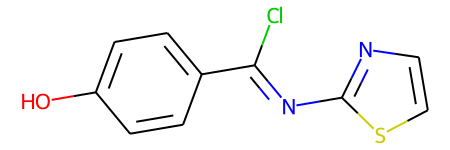

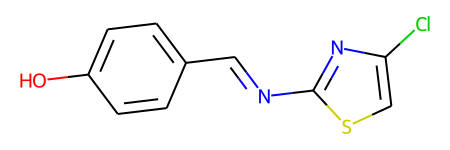

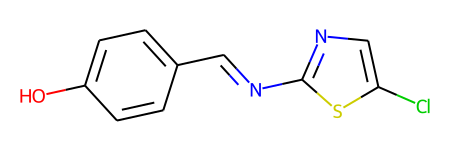

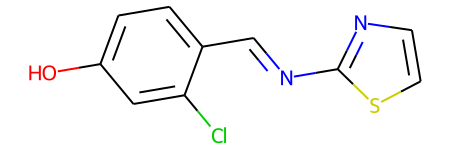

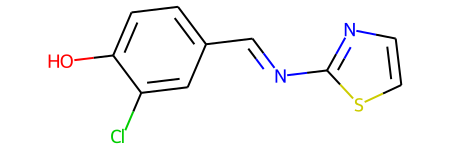

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


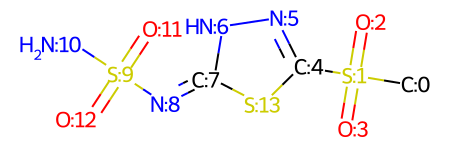

AUGMENTED MOLECULES
1 Explicit valence for atom # 1 S, 7, is greater than permitted
2 Explicit valence for atom # 2 O, 3, is greater than permitted
3 Explicit valence for atom # 3 O, 3, is greater than permitted
7 Explicit valence for atom # 7 C, 6, is greater than permitted
8 Explicit valence for atom # 8 N, 4, is greater than permitted
9 Explicit valence for atom # 9 S, 7, is greater than permitted
11 Explicit valence for atom # 11 O, 3, is greater than permitted
12 Explicit valence for atom # 12 O, 3, is greater than permitted
[0, 1, 2, 3, 5, 7, 8, 9, 10, 11, 12]


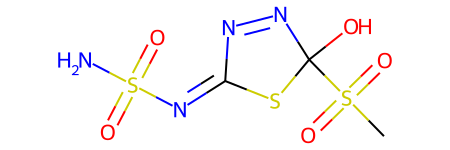

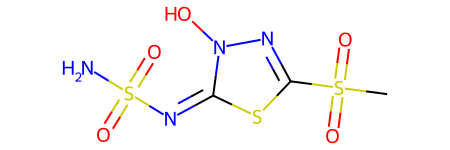

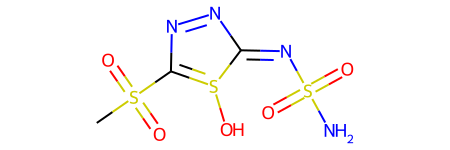

In [16]:
from rdkit_utils import *
from graph_augs import *

# from graph_augs import add_atom_everywhere

subs = ['Br','I','C','N','S','P','O','F','Cl']
for _,row in df.iterrows():    
    print('- '*40)
    mol = Chem.MolFromSmiles( canonicalize_smiles(row['smiles']))    
    mol_show = show_atom_index(mol)
    display(mol_show)
    print('AUGMENTED MOLECULES')
    try:
        aug_mols, bad_aidc = add_atom_everywhere(mol)
        print(bad_aidc)
        for g in aug_mols:
            display(g)
    except Exception as e:
        continue